* Seeting up a virtual environment is needed, the codes are in the following:


conda create -n econml-py39 python=3.9
conda activate econml-py39
pip install numpy==1.23.5 scipy==1.10.1 pandas==1.5.3 scikit-learn==1.2.2 matplotlib==3.6.3 seaborn==0.12.2 xgboost==1.7.5 lightgbm==3.3.5 shap==0.43.0 econml==0.15.0

pip install ipykernel
python -m ipykernel install --user --name econml-py39 --display-name econml-py39


In [4]:
from econml.grf import CausalForest
import numpy as np
import scipy.special
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from linearmodels.panel import PanelOLS
from docx import Document
from docx.shared import Inches
import scipy.stats as stats
from scipy.stats import pearsonr
import statsmodels.api as sm
from statsmodels.iolib.summary2 import summary_col

In [5]:
df = pd.read_csv('cemlcbq2vszshspq.csv')
df['derhedgl_binary'] = df['derhedgl'].apply(lambda x: 0 if pd.isna(x) else 1) #dummy for derivative use
# Filtering data by total assets,total debt, market value. If there was any 0 value during the research period, the company(gvkey) is delated
df = df[df['fyear'] >= 2013] #due to data availbility, I will use the period from 2013 to 2023 
to_exclude = df[(df['at'] == 0) | (df['dt'] == 0) | (df['mkvalt'] == 0 )|(df['ni'] == 0)|(df['capx']==0)
                  ].gvkey.unique()
filtered_data = df[~df['gvkey'].isin(to_exclude)]
filtered_data = filtered_data.dropna(subset= ['dt','mkvalt','capx','at','ni','lt'])
filtered_data.isna().sum()
filtered_len = len(filtered_data)
filtered_data['derhedgl_binary'].describe()
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])

filtered_data['ln_at'] = np.log(filtered_data['at'])
filtered_data['ln_dt'] = np.log(filtered_data['dt'])
filtered_data['ln_mkvalt'] = np.log(filtered_data['mkvalt'])
filtered_data['ln_lt'] = np.log(filtered_data['lt'])
filtered_data['current_ratio'] = filtered_data['ln_at'] - filtered_data['ln_lt']
filtered_data['debt_to_equity'] = filtered_data['ln_dt'] / (filtered_data['ln_at'] - filtered_data['ln_dt'])                                                                        
filtered_data['tobins_q'] = (filtered_data['mkvalt']) / filtered_data['at']
filtered_data['ROA'] = filtered_data['ni']/filtered_data['at']
filtered_data['leverage'] = filtered_data['dt']/filtered_data['at']
filtered_data['sic_group'] = filtered_data['sic'].astype(str).str[:1]
sic_group_dummies = pd.get_dummies(filtered_data['sic_group'], prefix='sic_group')
filtered_data = pd.concat([filtered_data, sic_group_dummies], axis=1)
print(len(filtered_data))
filtered_data.isna().sum()

filtered_data.to_csv('filtered_data.csv', index=False)





C:\Users\85832\AppData\Local\Temp\ipykernel_32288\2627939894.py:1: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('cemlcbq2vszshspq.csv')


30573


In [6]:
#User, Non-User comparison table. Annual Distribution of Derivatives Users (2013-2023)

yearly_stats = filtered_data.groupby('fyear').agg(
    N=('gvkey', 'count'),  
    Users=('derhedgl_binary', lambda x: (x == 1).sum()),  
    Non_users=('derhedgl_binary', lambda x: (x == 0).sum())  
).reset_index()

yearly_stats['% users'] = (yearly_stats['Users'] / yearly_stats['N'] * 100).round(2)
yearly_stats['% non-users'] = (yearly_stats['Non_users'] / yearly_stats['N'] * 100).round(2)

yearly_stats = yearly_stats.sort_values('fyear')

full_years = pd.DataFrame({'fyear': range(2013, 2024)})
yearly_stats = pd.merge(full_years, yearly_stats, on='fyear', how='left')
yearly_stats = yearly_stats.rename(columns={
    'fyear': 'Year',
    'Non_users': 'Non-users',
    '% users': '% users',
    '% non-users': '% non-users'
})

print(yearly_stats.to_string(index=False))
yearly_stats.to_csv('derivative_usage_by_year.csv',index = False)


 Year    N  Users  Non-users  % users  % non-users
 2013 3136   1045       2091    33.32        66.68
 2014 3059   1082       1977    35.37        64.63
 2015 2889   1021       1868    35.34        64.66
 2016 2717    943       1774    34.71        65.29
 2017 2620    876       1744    33.44        66.56
 2018 2597    868       1729    33.42        66.58
 2019 2523    820       1703    32.50        67.50
 2020 2474    785       1689    31.73        68.27
 2021 2833    935       1898    33.00        67.00
 2022 2875    977       1898    33.98        66.02
 2023 2850    965       1885    33.86        66.14


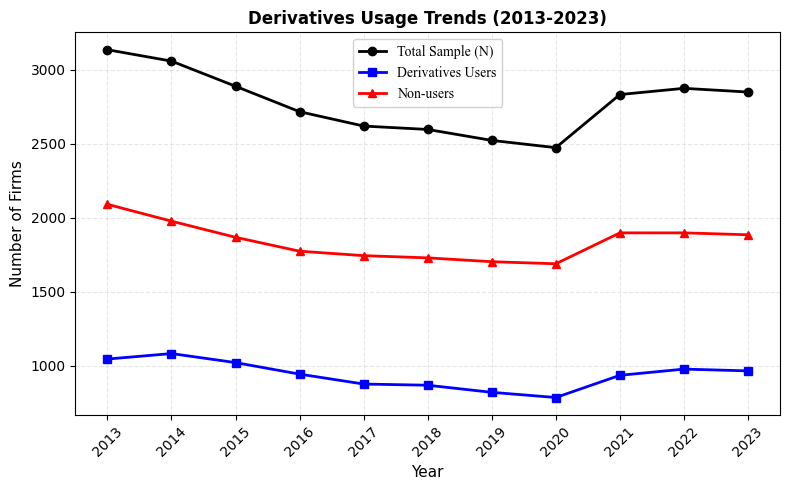

In [7]:
# Plot for user and non users fig:derivatives_trend

fig, ax = plt.subplots(figsize=(8, 5))
plt.rcParams.update({
    'font.family': 'Times New Roman',
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})


ax.plot(yearly_stats['Year'], yearly_stats['N'], 
        'ko-', label='Total Sample (N)', linewidth=2, markersize=6)
ax.plot(yearly_stats['Year'], yearly_stats['Users'], 
        'bs-', label='Derivatives Users', linewidth=2, markersize=6)
ax.plot(yearly_stats['Year'], yearly_stats['Non-users'], 
        'r^-', label='Non-users', linewidth=2, markersize=6)

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Firms', fontsize=11)
ax.set_title('Derivatives Usage Trends (2013-2023)', fontsize=12, fontweight='bold')


ax.set_xticks(yearly_stats['Year'])
ax.set_xticklabels(yearly_stats['Year'], rotation=45)


ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, framealpha=0.9)


plt.tight_layout()


plt.savefig('derivatives_trend_simple.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [8]:
#Descriptive tab:desc_stats

def create_descriptive_stats_by_hedge(df, variables):
    
    results = []

    for var in variables:

        all_stats = {
            'Variable': var,
            'Group': 'All firms',
            'N': df[var].count(),
            'Mean': df[var].mean(),
            'Median': df[var].median(),
            'St. Dev.': df[var].std()
        }
        results.append(all_stats)
        
        non_users = df[df['derhedgl_binary'] == 0]
        non_stats = {
            'Variable': var,
            'Group': 'Non-users',
            'N': non_users[var].count(),
            'Mean': non_users[var].mean(),
            'Median': non_users[var].median(),
            'St. Dev.': non_users[var].std()
        }
        results.append(non_stats)

    
        users = df[df['derhedgl_binary'] == 1]
        user_stats = {
            'Variable': var,
            'Group': 'Users',
            'N': users[var].count(),
            'Mean': users[var].mean(),
            'Median': users[var].median(),
            'St. Dev.': users[var].std()
        }
        results.append(user_stats)

    results_df = pd.DataFrame(results)  

    for col in ['Mean', 'Median', 'St. Dev.']:
        results_df[col] = results_df[col].apply(lambda x: f"{x:,.4f}" if pd.notnull(x) else "")
    results_df['N'] = results_df['N'].astype(int)

    return results_df

assert 'derhedgl_binary' in filtered_data.columns
assert set(filtered_data['derhedgl_binary'].unique()).issubset({0, 1})


selected_variables = ['at', 'dt', 'mkvalt', 'ROA', 'tobins_q', 'leverage']  # Variables

descriptive_table = create_descriptive_stats_by_hedge(filtered_data, selected_variables)

for var in selected_variables:
    var_data = descriptive_table[descriptive_table['Variable'] == var]
    print(f"\nVariable: {var}")
    print("-" * 40)
    print(var_data[['Group', 'N', 'Mean', 'Median', 'St. Dev.']].to_string(index=False))


descriptive_table.to_csv('descriptive_stats_by_hedge.csv', index=False)




Variable: at
----------------------------------------
    Group     N        Mean     Median    St. Dev.
All firms 30573 11,118.3104 1,294.7690 64,632.7774
Non-users 20256 11,552.0483 1,079.4950 76,670.1072
    Users 10317 10,266.7263 1,818.6620 28,931.7711

Variable: dt
----------------------------------------
    Group     N       Mean   Median    St. Dev.
All firms 30573 2,865.0156 365.3360 10,730.7508
Non-users 20256 2,601.8264 290.5365 11,194.8491
    Users 10317 3,381.7512 551.1270  9,735.3852

Variable: mkvalt
----------------------------------------
    Group     N        Mean     Median    St. Dev.
All firms 30573 10,011.8596 1,037.1793 55,657.5298
Non-users 20256  8,686.0604   886.9195 53,550.4570
    Users 10317 12,614.8825 1,344.0872 59,494.8913

Variable: ROA
----------------------------------------
    Group     N    Mean Median St. Dev.
All firms 30573 -0.2254 0.0188  18.9272
Non-users 20256 -0.2408 0.0208  22.9843
    Users 10317 -0.1950 0.0150   4.9406

Variable: tobi

In [9]:
#filtering data with hdgl_binary=1 for further test
#if thereis na still using the following code to clean again
#filtered_data = filtered_data[(filtered_data['capx'] != 0) & (filtered_data['capx'].notna()) &
#(filtered_data['derhedgl'].notna()) &(filtered_data['ni'].notna())]

der_set = filtered_data[filtered_data['derhedgl_binary'] == 1]

print(der_set.describe())

der_set.to_csv('der_set.csv', index=False)

              fyear          gvkey         exchg           gind           sic  \
count  10317.000000   10317.000000  10317.000000   10314.000000  10317.000000   
mean    2017.859455   77903.751187     13.964815  276963.687221   3966.935543   
std        3.253569   76011.662626      3.209111  135587.937725   2083.600403   
min     2013.000000    1050.000000      1.000000  101010.000000    100.000000   
25%     2015.000000   15044.000000     11.000000  151040.000000   2810.000000   
50%     2018.000000   36952.000000     14.000000  252030.000000   3663.000000   
75%     2021.000000  160255.000000     19.000000  352020.000000   5047.000000   
max     2023.000000  351491.000000     19.000000  602010.000000   9997.000000   

           curuscn    aocidergl             at             lt       cidergl  \
count  1729.000000  9894.000000   10317.000000   10317.000000  10256.000000   
mean      0.792086    -3.535849   10266.726259    6675.795781     -0.118977   
std       0.068789    85.703132  

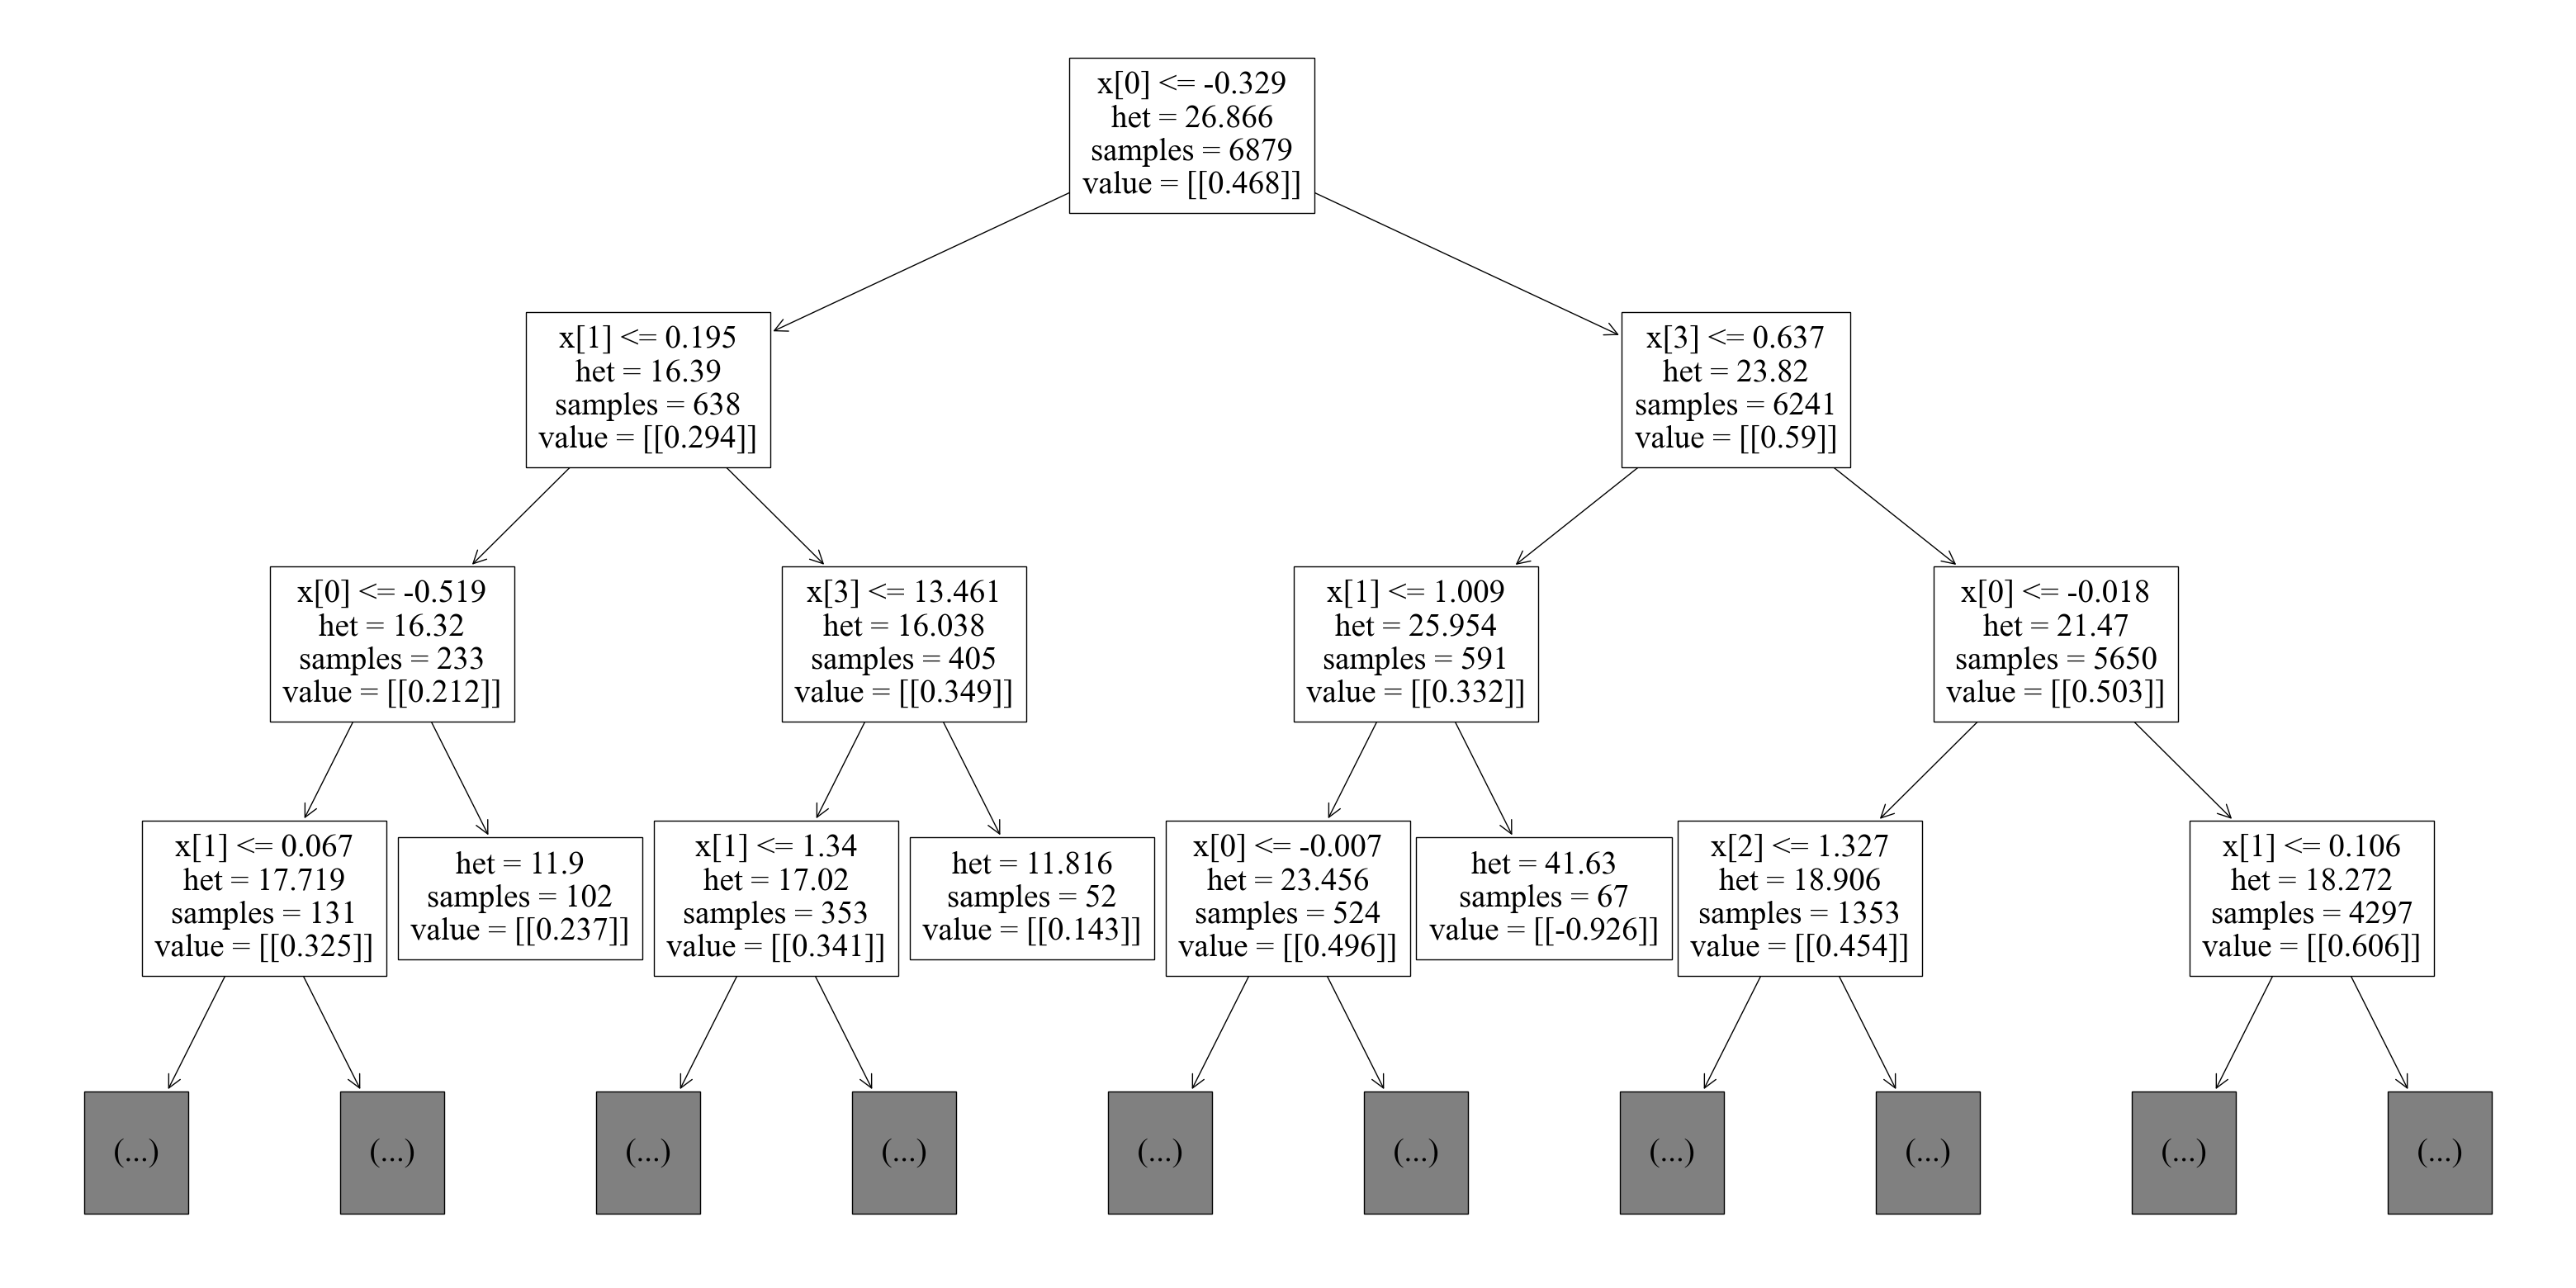

ATE: 0.3322
SE: 0.0016
95%confidentual: [0.3291, 0.3353]


In [17]:
# First casual forest
X = filtered_data[['ROA', 'leverage', 'current_ratio', 'debt_to_equity']].values
T = filtered_data['derhedgl_binary'].values
y = filtered_data['ln_mkvalt'].values.reshape(-1, 1)


# setting CausalForest， min leaf is 50 to prevent over-fitting
est = CausalForest(criterion='het', n_estimators=2000, min_samples_leaf=50, max_depth=20,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)

ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")

CATE from ATE: 0.3322


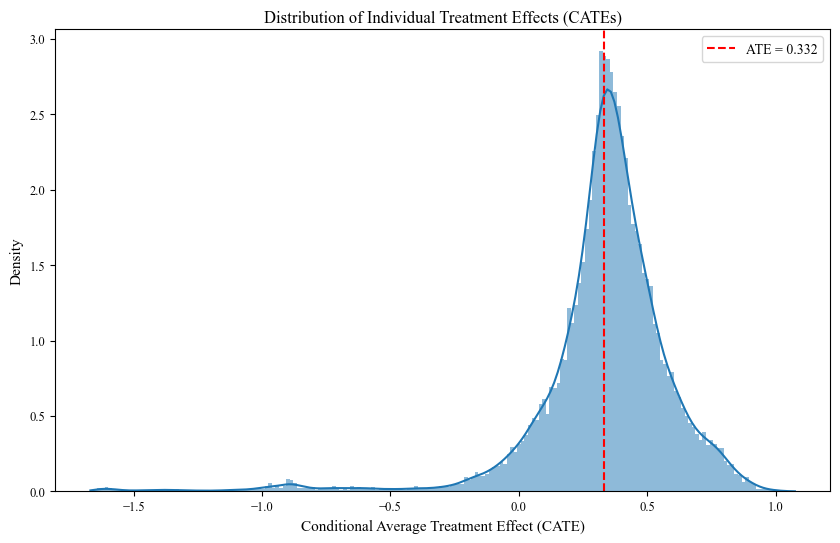

In [11]:
import seaborn as sns
cates = est.predict(X)
ate_value = np.mean(cates)
print (f"CATE from ATE: {ate_value:.4f}")
plt.figure(figsize=(10, 6))
sns.histplot(cates, kde=True, stat="density", linewidth=0)
plt.axvline(ate_value, color='red', linestyle='--', label=f'ATE = {ate_value:.3f}')
plt.xlabel('Conditional Average Treatment Effect (CATE)')
plt.ylabel('Density')
plt.title('Distribution of Individual Treatment Effects (CATEs)')
plt.legend()
plt.show()
#\caption{Distribution of Individual Treatment Effects Derivatives Usage among Companies (2013-2023)} 

In [12]:
ite = est.predict(X).flatten()

# Add ITE back to original data
df_analysis = filtered_data.copy()
df_analysis['ITE'] = ite

# ============ 2. Select top 20% ITE companies ============
top_percent = 0.20   # can adjust to 0.10 or 0.30
threshold = np.quantile(ite, 1 - top_percent)

df_high_ite = df_analysis[df_analysis['ITE'] >= threshold]

print("Number of high-ITE companies:", len(df_high_ite))

# ============ 3. Summarize feature means ============
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

high_ite_profile = df_high_ite[feature_cols].describe()
overall_profile = df_analysis[feature_cols].describe()

print("\n=== High-ITE Company Profile (Top 20%) ===")
print(high_ite_profile)

print("\n=== Overall Company Profile ===")
print(overall_profile)

# ============ 4. Compare difference ============
diff = high_ite_profile.loc['mean'] - overall_profile.loc['mean']
print("\n=== Difference Between High-ITE and Overall (means) ===")
print(diff.sort_values(ascending=False))


Number of high-ITE companies: 6115

=== High-ITE Company Profile (Top 20%) ===
               ROA      leverage  current_ratio  debt_to_equity
count  6115.000000  6.115000e+03    6115.000000     6115.000000
mean     -0.044722  4.508763e-01       0.438432        7.454218
std       1.179209  7.639176e-01       0.641884        8.118195
min     -78.174192  9.597703e-07      -3.608474      -58.352035
25%      -0.015398  2.198649e-01       0.116483        2.338465
50%       0.036447  3.765593e-01       0.344167        5.468242
75%       0.107583  5.551825e-01       0.663665       10.926179
max       3.606467  2.264922e+01       4.641054       82.850605

=== Overall Company Profile ===
                ROA      leverage  current_ratio  debt_to_equity
count  30573.000000  3.057300e+04   30573.000000    30573.000000
mean      -0.225364  3.840474e-01       0.574617        3.912972
std       18.927187  4.791713e+00       0.583005      372.442743
min    -3267.666667  9.597703e-07      -7.269849   -


Feature Importance Ranking
Rank  Feature              Importance %       
------------------------------------------------------------
1     ROA                  0.443      44.3    %
2     Current_Ratio        0.220      22.0    %
3     Leverage             0.184      18.4    %
4     Debt_to_Equity       0.153      15.3    %


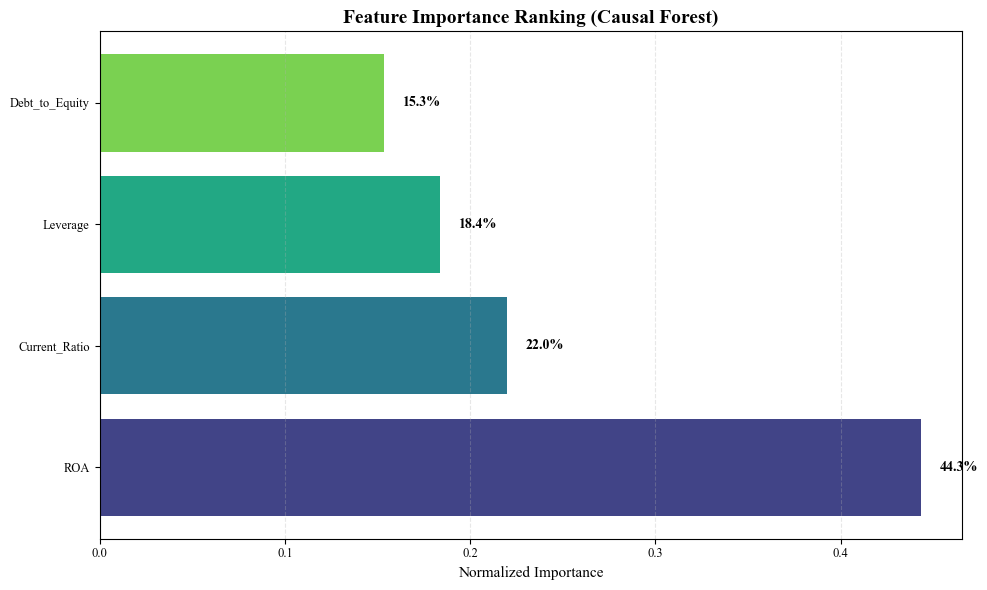


Results saved to: feature_importance_ranking.csv


In [20]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import cm
matplotlib.rcParams['text.usetex'] = False
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Helvetica']

# setting names
feature_names = ['ROA', 'Leverage', 'Current_Ratio', 'Debt_to_Equity']

# get ranks
if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
else:
    importance = np.ones(len(feature_names)) / len(feature_names)

# standerlize 
if importance.sum() > 0:
    importance_norm = importance / importance.sum()


df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance,
    'Normalized': importance_norm,
    'Percentage': importance_norm * 100
})

df = df.sort_values('Normalized', ascending=False)
df['Rank'] = range(1, len(df) + 1)


print("\n" + "="*60)
print("Feature Importance Ranking")
print("="*60)
print(f"{'Rank':<5} {'Feature':<20} {'Importance':<10} {'%':<8}")
print("-"*60)

for _, row in df.iterrows():
    print(f"{row['Rank']:<5} {row['Feature']:<20} {row['Normalized']:<10.3f} {row['Percentage']:<8.1f}%")

print("="*60)


plt.figure(figsize=(10, 6))
colors = cm.viridis(np.linspace(0.2, 0.8, len(df)))
bars = plt.barh(df['Feature'], df['Normalized'], color=colors)
plt.xlabel('Normalized Importance')
plt.title('Feature Importance Ranking (Causal Forest)', fontsize=14, fontweight='bold')

for bar, value in zip(bars, df['Normalized']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1%}', va='center', fontweight='bold')

plt.grid(True, axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(Ranking_binanry.pdf)
plt.show()

#\caption{Feature Importance Ranking: Contribution to Heterogeneity in Causal Forest Model}
df.to_csv('feature_importance_ranking.csv', index=False)
print("\nResults saved to: feature_importance_ranking.csv")

In [ ]:
# \caption{T-Test Results: High ITE vs Overall Sample} \label{tab:t_test_results}
from scipy.stats import ttest_ind
import pandas as pd
import numpy as np

# feature list
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

results = []

for col in feature_cols:
    high_group = df_high_ite[col].dropna()
    overall_group = df_analysis[col].dropna()

    # Welch’s t-test (unequal variance)
    t_stat, p_val = ttest_ind(high_group, overall_group, equal_var=False)

    # effect direction (mean difference)
    mean_diff = high_group.mean() - overall_group.mean()

    # significance stars
    if p_val < 0.01:
        sig = "***"
    elif p_val < 0.05:
        sig = "**"
    elif p_val < 0.1:
        sig = "*"
    else:
        sig = ""

    results.append({
        "feature": col,
        "mean_high_ITE": high_group.mean(),
        "mean_overall": overall_group.mean(),
        "mean_diff": mean_diff,
        "t_stat": t_stat,
        "p_value": p_val,
        "significance": sig
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(results)
ttest_df = ttest_df.sort_values("mean_diff", ascending=False)


print("\n=== T-test Results: High ITE vs Overall ===")
print(ttest_df)


In [ ]:
feature_names = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

imp = est.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": imp
}).sort_values("importance", ascending=False)

print(df_imp)


In [ ]:
#Causal Forest Feature Importance (Split Frequency) figure
plt.figure(figsize=(8,5))
plt.bar(df_imp['feature'], df_imp['importance'])
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.title("Causal Forest Feature Importance (Split Frequency)")
plt.tight_layout()
plt.show()

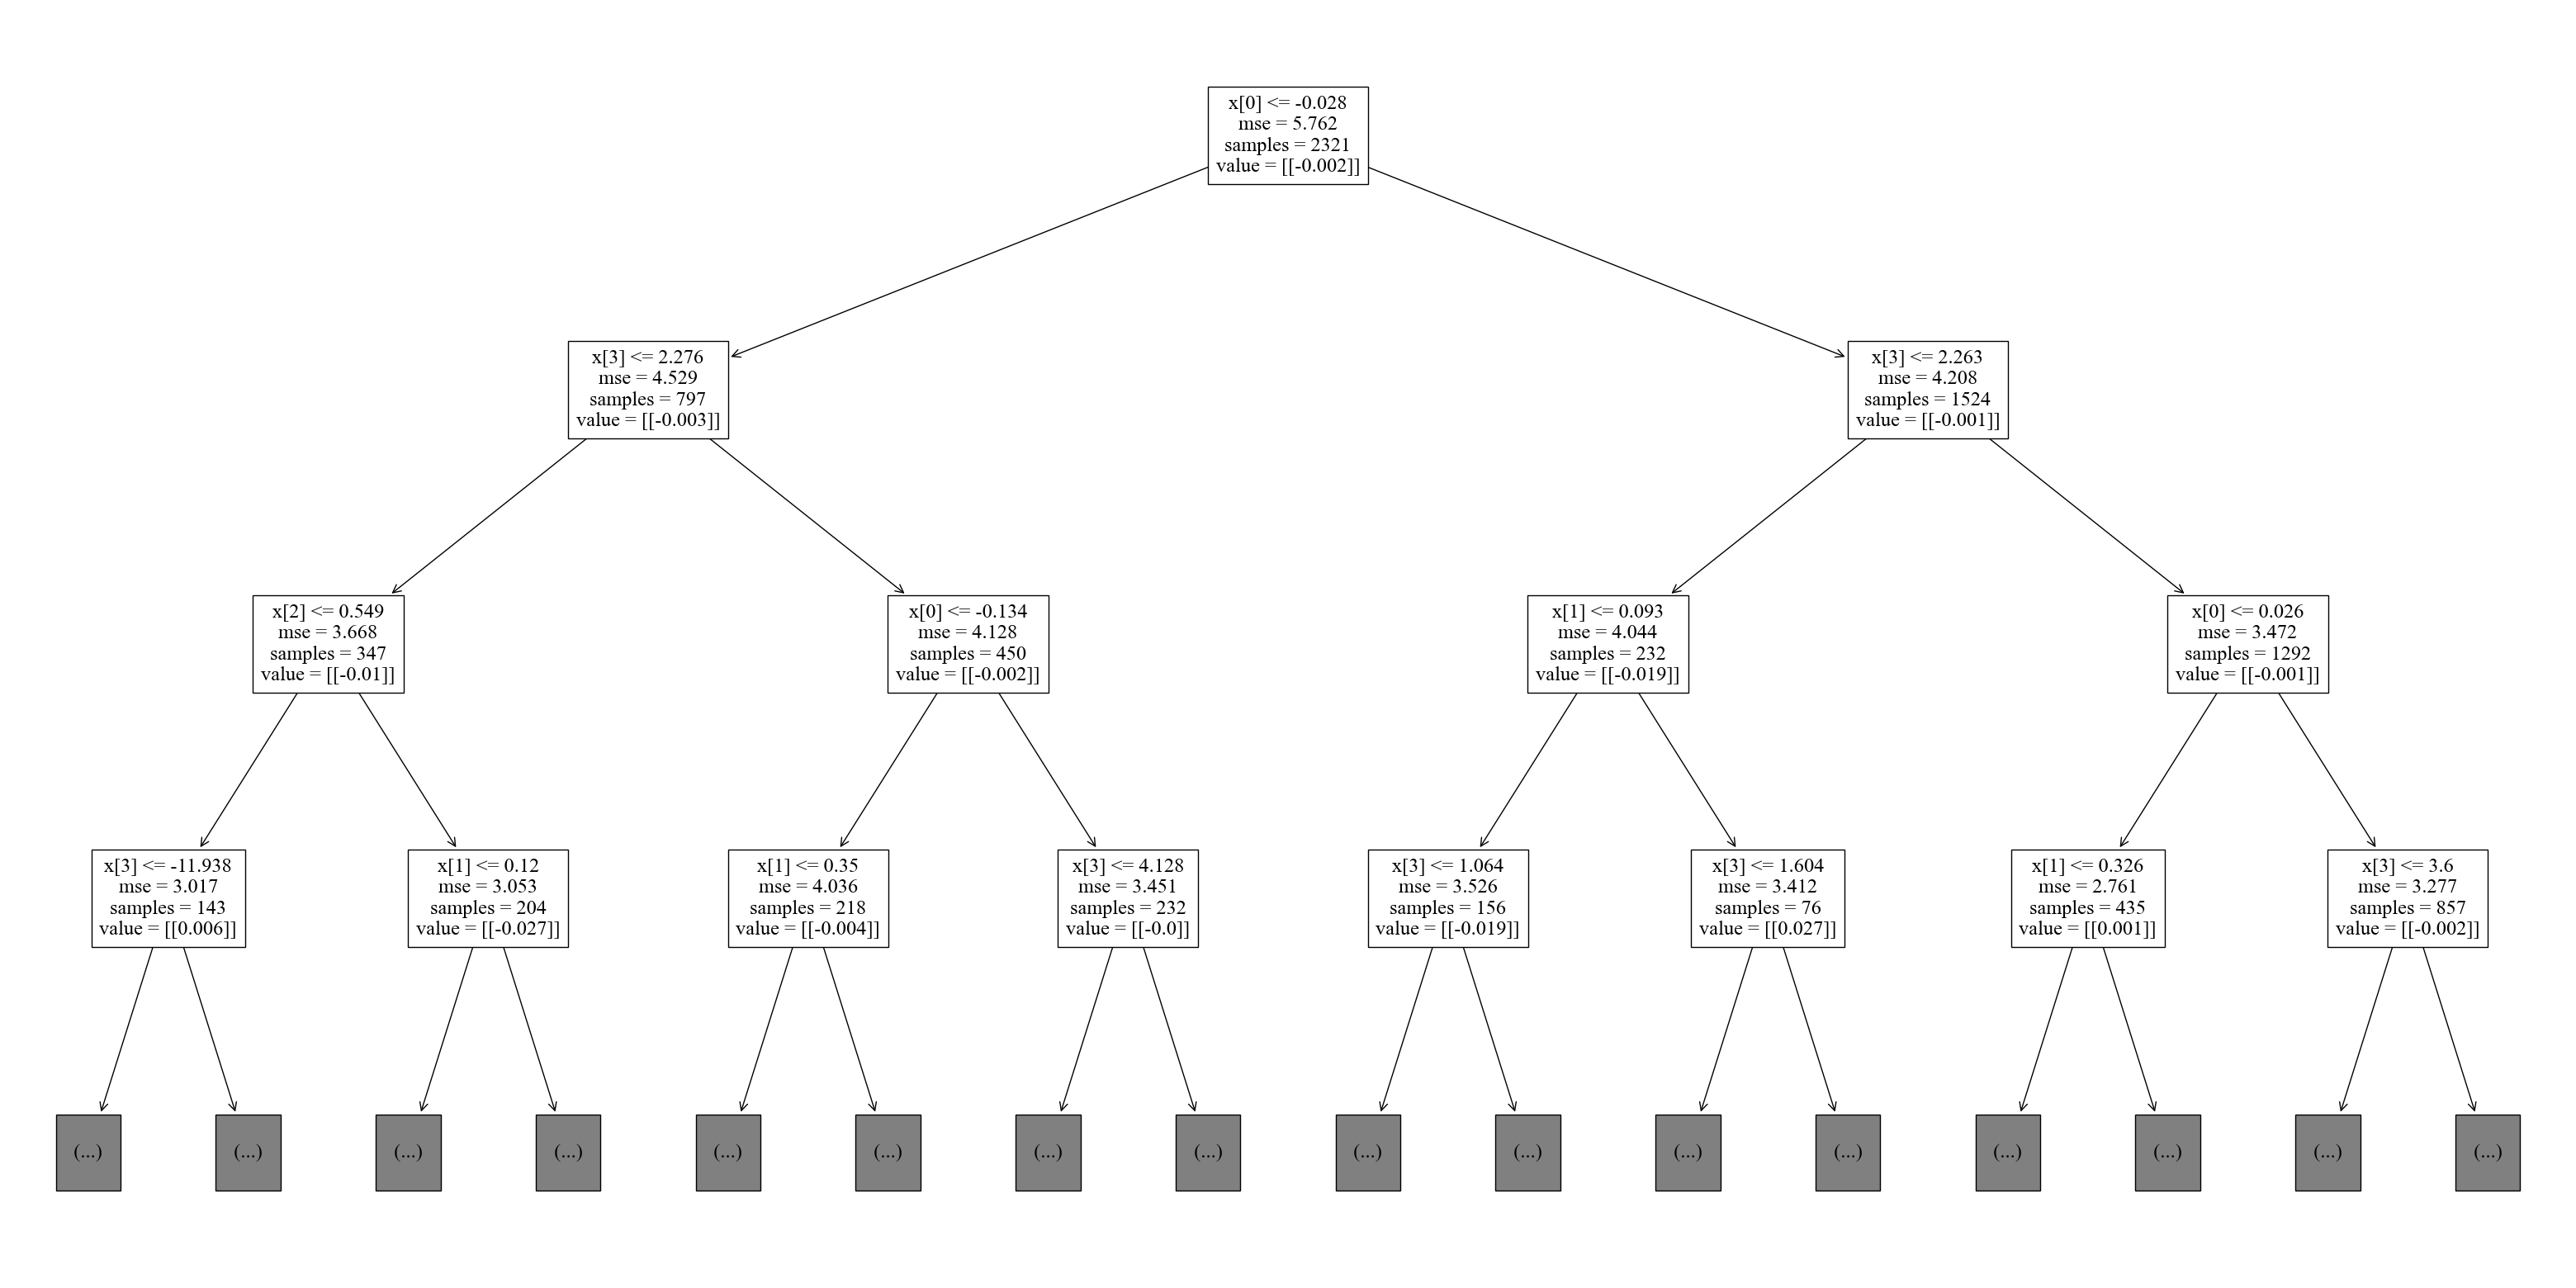

ATE: -0.0018
SE: 0.0000
95%confidentual: [-0.0019, -0.0017]


In [21]:
X = der_set[['ROA', 'leverage', 'current_ratio', 'debt_to_equity']].values
T = der_set['derhedgl'].values
y = der_set['ln_mkvalt'].values.reshape(-1, 1)


# setting CausalForest
est = CausalForest(criterion='mse', n_estimators=2000, min_samples_leaf=5, max_depth=None,
                   min_var_fraction_leaf=None, min_var_leaf_on_val=True,
                    max_samples=0.45, min_balancedness_tol=.45,
                   warm_start=False, inference=True, fit_intercept=True, subforest_size=4,
                   honest=True, verbose=0, n_jobs=-1, random_state=1235)


est.fit(X, T, y)

plt.figure(figsize=(40, 20))
plot_tree(est[0], impurity=True,  max_depth=3)
plt.show()

individual_effects = est.predict(X)
ate = np.mean(individual_effects)
ate_se = np.std(individual_effects) / np.sqrt(len(individual_effects))
print(f"ATE: {ate:.4f}")
print(f"SE: {ate_se:.4f}")
print(f"95%confidentual: [{ate - 1.96*ate_se:.4f}, {ate + 1.96*ate_se:.4f}]")


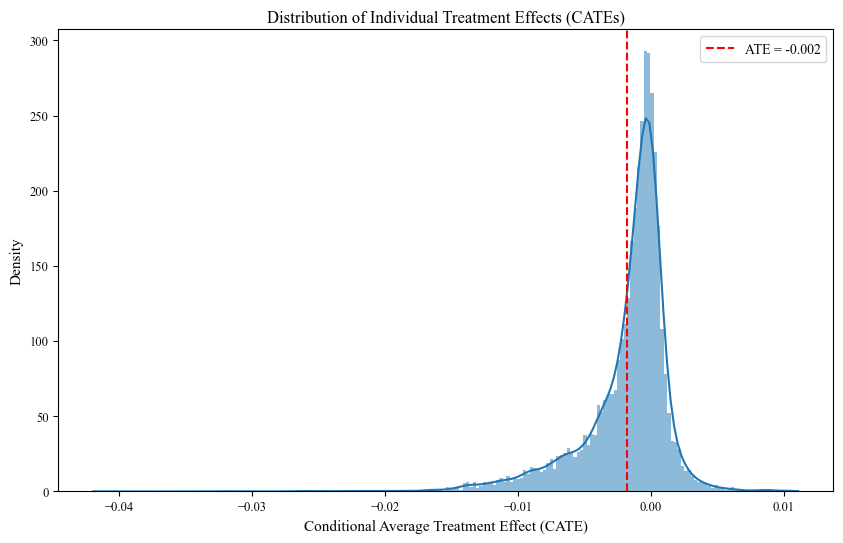

In [23]:
# \caption{Distribution of Individual Treatment Effects Derivatives Usage among Companies (2013-2023)} \label{fig:CATE_Kde_derhedgl}
cates = est.predict(X)
ate_value = np.mean(cates)
plt.figure(figsize=(10, 6))
sns.histplot(cates, kde=True, stat="density", linewidth=0)
plt.axvline(ate_value, color='red', linestyle='--', label=f'ATE = {ate_value:.3f}')
plt.xlabel('Conditional Average Treatment Effect (CATE)')
plt.ylabel('Density')
plt.title('Distribution of Individual Treatment Effects (CATEs)')
plt.legend()
plt.savefig('CATE_Kde_derhedgl.pdf', dpi=300, bbox_inches='tight', pad_inches=0.1)
plt.show()



Feature Importance Ranking
Rank  Feature              Importance %       
------------------------------------------------------------
1     Debt_to_Equity       0.351      35.1    %
2     Leverage             0.323      32.3    %
3     Current_Ratio        0.184      18.4    %
4     ROA                  0.142      14.2    %


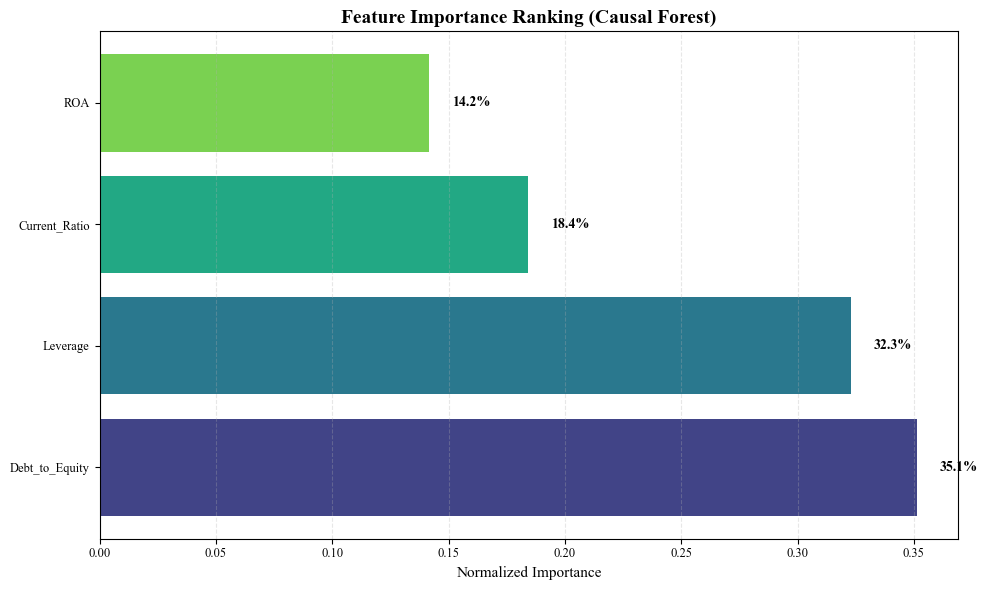


Results saved.csv


In [27]:
#\caption{Feature Importance Ranking: Contribution to Heterogeneity in Causal Forest Model(Derivative gain or loss )}
feature_names = ['ROA', 'Leverage', 'Current_Ratio', 'Debt_to_Equity']


if hasattr(est, 'feature_importances_'):
    importance = est.feature_importances_
else:
    importance = np.ones(len(feature_names)) / len(feature_names)


if importance.sum() > 0:
    importance_norm = importance / importance.sum()


df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Score': importance,
    'Normalized': importance_norm,
    'Percentage': importance_norm * 100
})

df = df.sort_values('Normalized', ascending=False)
df['Rank'] = range(1, len(df) + 1)


for _, row in df.iterrows():
    print(f"{row['Rank']:<5} {row['Feature']:<20} {row['Normalized']:<10.3f} {row['Percentage']:<8.1f}%")

print("="*60)


plt.figure(figsize=(10, 6))
bars = plt.barh(df['Feature'], df['Normalized'], color=colors)
plt.xlabel('Normalized Importance')
plt.title('Feature Importance Ranking (Causal Forest)', fontsize=14, fontweight='bold')

for bar, value in zip(bars, df['Normalized']):
    plt.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{value:.1%}', va='center', fontweight='bold')

plt.grid(True, axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('feature_importance_ranking_derhedgl.pdf',dpi=300, bbox_inches='tight', pad_inches=0.1 )
plt.show()


df.to_csv('feature_importance_ranking_derhedgl.csv', index=False)
print("\nResults saved.csv")

In [31]:
ite = est.predict(X).flatten()

# Add ITE back to original data
df_analysis = der_set.copy()
df_analysis['ITE'] = ite


# ============ 2. Select top 20% ITE companies ============
top_percent = 0.20   # can adjust to 0.10 or 0.30
threshold = np.quantile(ite, 1 - top_percent)

df_high_ite = df_analysis[df_analysis['ITE'] >= threshold]

print("Number of high-ITE companies:", len(df_high_ite))

# ============ 3. Summarize feature means ============
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

high_ite_profile = df_high_ite[feature_cols].describe()
overall_profile = df_analysis[feature_cols].describe()

print("\n=== High-ITE Company Profile (Top 20%) ===")
print(high_ite_profile)

print("\n=== Overall Company Profile ===")
print(overall_profile)

# ============ 4. Compare difference ============
diff = high_ite_profile.loc['mean'] - overall_profile.loc['mean']
print("\n=== Difference Between High-ITE and Overall (means) ===")
print(diff.sort_values(ascending=False))


Number of high-ITE companies: 2064

=== High-ITE Company Profile (Top 20%) ===
               ROA     leverage  current_ratio  debt_to_equity
count  2064.000000  2064.000000    2064.000000     2064.000000
mean     -0.024835     0.293623       0.725257        6.165733
std       0.236553     0.172400       0.469986        5.581776
min      -1.995178     0.000369      -0.483547       -0.203219
25%      -0.037270     0.144161       0.405242        2.522438
50%       0.025138     0.287551       0.609156        4.954703
75%       0.057112     0.399032       0.971021        8.208275
max       3.606467     0.910341       3.082037       79.991638

=== Overall Company Profile ===
                ROA      leverage  current_ratio  debt_to_equity
count  10317.000000  10317.000000   10317.000000    10317.000000
mean      -0.195032      0.368571       0.538768        6.987132
std        4.940648      0.463098       0.572401      143.378742
min     -480.000000      0.000014      -6.142037   -11325.634

In [32]:

from scipy.stats import ttest_ind

# \caption{T-Test Results: High ITE vs Overall Sample} \label{tab:t_test_results}

# feature list
feature_cols = ['ROA', 'leverage', 'current_ratio', 'debt_to_equity']

results = []

for col in feature_cols:
    high_group = df_high_ite[col].dropna()
    overall_group = df_analysis[col].dropna()

    # Welch’s t-test (unequal variance)
    t_stat, p_val = ttest_ind(high_group, overall_group, equal_var=False)

    # effect direction (mean difference)
    mean_diff = high_group.mean() - overall_group.mean()

    # significance stars
    if p_val < 0.01:
        sig = "***"
    elif p_val < 0.05:
        sig = "**"
    elif p_val < 0.1:
        sig = "*"
    else:
        sig = ""

    results.append({
        "feature": col,
        "mean_high_ITE": high_group.mean(),
        "mean_overall": overall_group.mean(),
        "mean_diff": mean_diff,
        "t_stat": t_stat,
        "p_value": p_val,
        "significance": sig
    })

# Convert to DataFrame
ttest_df = pd.DataFrame(results)
ttest_df = ttest_df.sort_values("mean_diff", ascending=False)


print("\n=== T-test Results: High ITE vs Overall ===")
print(ttest_df)



=== T-test Results: High ITE vs Overall ===
          feature  mean_high_ITE  mean_overall  mean_diff     t_stat  \
2   current_ratio       0.725257      0.538768   0.186489  15.830559   
0             ROA      -0.024835     -0.195032   0.170197   3.479133   
1        leverage       0.293623      0.368571  -0.074948 -12.634774   
3  debt_to_equity       6.165733      6.987132  -0.821399  -0.579705   

        p_value significance  
2  1.602799e-54          ***  
0  5.050699e-04          ***  
1  2.825998e-36          ***  
3  5.621259e-01               
